# 04 - Contraindication Risk Classifier + SHAP

**Bio-Heritage AI: RAG-Based Sri Lankan Herb Knowledge Assistant**

Steps 8 & 9 of the methodology. We build a supervised safety layer:
1. Create a synthetic herb-patient contraindication dataset (synthetic data is allowed for this prototype).
2. Encode the categorical features and train a **Random Forest** classifier.
3. Predict one of three risk levels: **Safe / Caution / Contraindicated**.
4. Evaluate with accuracy, classification report, confusion matrix, and cross-validation.
5. Use **SHAP** to explain which features drive the predictions.
6. Save all model artifacts to `models/`.

Input features: `herb_name, patient_condition, medication_context, age_group, dosage_form`.

In [1]:
import os, json, pickle, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

random.seed(42); np.random.seed(42)

CHUNKS_PATH = "../chunks/herb_chunks.json"
if not os.path.exists(CHUNKS_PATH):
    CHUNKS_PATH = "chunks/herb_chunks.json"
BASE = os.path.normpath(os.path.join(os.path.dirname(CHUNKS_PATH), ".."))
DATA_DIR = os.path.join(BASE, "data"); os.makedirs(DATA_DIR, exist_ok=True)
MODEL_DIR = os.path.join(BASE, "models"); os.makedirs(MODEL_DIR, exist_ok=True)
DATASET_CSV = os.path.join(DATA_DIR, "herb_contraindication_risk_dataset.csv")

## 1. Build the synthetic contraindication dataset
We use real herb names, plus realistic patient contexts. A rule-based scorer assigns each row a risk level so the Random Forest can learn meaningful patterns (this demonstrates the technology; final medical validation would use verified sources).

In [2]:
# Real herb names from the knowledge base
with open(CHUNKS_PATH, "r", encoding="utf-8") as f:
    chunks = json.load(f)
herb_names = list(dict.fromkeys(
    [c["herb_name_english"].strip() for c in chunks if c.get("herb_name_english", "").strip()]
))
print("Herb names available:", len(herb_names))

patient_conditions = ["none", "pregnancy", "breastfeeding", "diabetes",
                      "hypertension", "kidney disease", "liver disease", "heart disease"]
medication_contexts = ["none", "antidiabetic", "antihypertensive", "anticoagulant", "antibiotics"]
age_groups = ["child", "adult", "elderly"]
dosage_forms = ["herbal tea", "powder", "capsule", "decoction"]

Herb names available: 378


In [3]:
def risk_score(cond, med, age, form):
    """Rule-based risk score -> higher means more risky."""
    s = 0
    s += {"none": 0, "pregnancy": 3, "breastfeeding": 2, "diabetes": 1,
          "hypertension": 1, "kidney disease": 2, "liver disease": 2, "heart disease": 1}[cond]
    s += {"none": 0, "antidiabetic": 1, "antihypertensive": 1,
          "anticoagulant": 3, "antibiotics": 1}[med]
    # dangerous herb-drug interaction combos
    if cond == "diabetes" and med == "antidiabetic":
        s += 2
    if cond == "hypertension" and med == "antihypertensive":
        s += 1
    s += {"child": 2, "adult": 0, "elderly": 1}[age]
    s += {"herbal tea": 0, "powder": 0, "capsule": 1, "decoction": 1}[form]
    s += np.random.choice([0, 0, 0, 1])  # small realistic noise
    return s

def score_to_level(s):
    if s <= 1:
        return "Safe"
    elif s <= 4:
        return "Caution"
    return "Contraindicated"

def reason_text(cond, med, age):
    parts = []
    if cond != "none": parts.append(cond)
    if med != "none": parts.append(f"use of {med} medication")
    if age != "adult": parts.append(f"{age} age group")
    return "Influenced by " + ", ".join(parts) if parts else "No major risk factors"

N = 3000
rows = []
for _ in range(N):
    herb = random.choice(herb_names)
    cond = random.choice(patient_conditions)
    med = random.choice(medication_contexts)
    age = random.choice(age_groups)
    form = random.choice(dosage_forms)
    s = risk_score(cond, med, age, form)
    rows.append({
        "herb_name": herb, "patient_condition": cond, "medication_context": med,
        "age_group": age, "dosage_form": form,
        "risk_level": score_to_level(s), "risk_score": s,
        "reason": reason_text(cond, med, age)
    })

data = pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)
data.to_csv(DATASET_CSV, index=False, encoding="utf-8")
print("Dataset rows:", len(data))
print(data["risk_level"].value_counts())
data.head()

Dataset rows: 2984
risk_level
Contraindicated    1491
Caution            1407
Safe                 86
Name: count, dtype: int64


,herb_name,patient_condition,medication_context,age_group,dosage_form,risk_level,risk_score,reason
0,sacred medick,pregnancy,none,elderly,capsule,Contraindicated,5,"Influenced by pregnancy, elderly age group"
1,Headache tree,diabetes,antidiabetic,elderly,herbal tea,Contraindicated,6,"Influenced by diabetes, use of antidiabetic me..."
2,wild bitterleaf,pregnancy,antibiotics,adult,herbal tea,Caution,4,"Influenced by pregnancy, use of antibiotics me..."
3,Bitter gourd,pregnancy,antidiabetic,child,herbal tea,Contraindicated,6,"Influenced by pregnancy, use of antidiabetic m..."
4,forest stoneroot,diabetes,antibiotics,adult,powder,Caution,2,"Influenced by diabetes, use of antibiotics med..."


## 2. Encode features and train the Random Forest

In [4]:
feature_columns = ["herb_name", "patient_condition", "medication_context", "age_group", "dosage_form"]

# Label-encode each categorical feature; keep the encoders so the app can reuse them.
feature_encoders = {}
X = pd.DataFrame()
for col in feature_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(data[col])
    feature_encoders[col] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(data["risk_level"])  # Safe/Caution/Contraindicated -> 0/1/2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


## 3. Evaluate

Accuracy: 0.8978

Classification report:

                 precision    recall  f1-score   support

        Caution       0.89      0.89      0.89       282
Contraindicated       0.92      0.91      0.91       298
           Safe       0.74      0.82      0.78        17

       accuracy                           0.90       597
      macro avg       0.85      0.87      0.86       597
   weighted avg       0.90      0.90      0.90       597



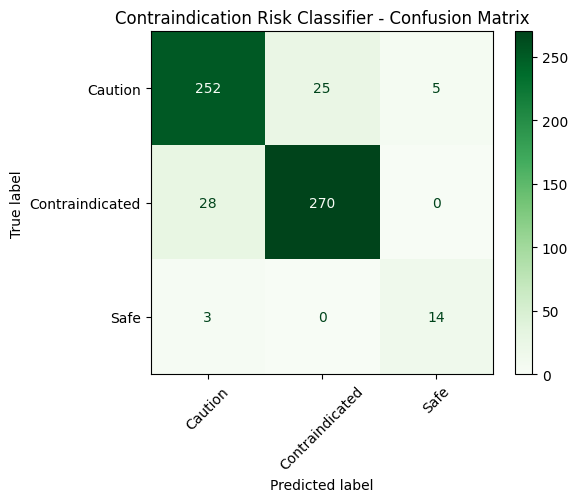

5-fold CV accuracy: 0.9065 (+/- 0.0068)


In [5]:
y_pred = rf.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, xticks_rotation=45, cmap="Greens")
plt.title("Contraindication Risk Classifier - Confusion Matrix")
plt.tight_layout(); plt.show()

cv = cross_val_score(rf, X, y, cv=5)
print("5-fold CV accuracy: %.4f (+/- %.4f)" % (cv.mean(), cv.std()))

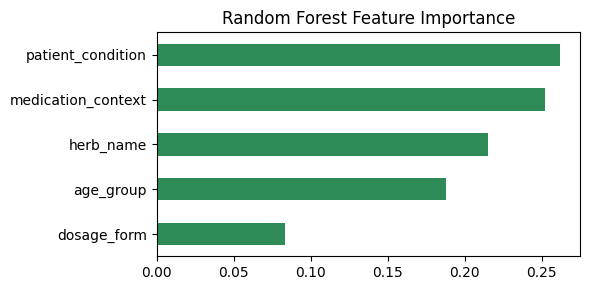

patient_condition     0.261708
medication_context    0.252168
herb_name             0.215338
age_group             0.187499
dosage_form           0.083287
dtype: float64


In [6]:
# Feature importance (which features matter most overall)
importances = pd.Series(rf.feature_importances_, index=feature_columns).sort_values()
importances.plot(kind="barh", figsize=(6, 3), color="seagreen")
plt.title("Random Forest Feature Importance")
plt.tight_layout(); plt.show()
print(importances.sort_values(ascending=False))

## 4. SHAP explainability
SHAP shows how each feature pushes a prediction toward or away from each risk level.

c:\Users\THANUJA\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\THANUJA\AppData\Local\Temp\ipykernel_11000\650857298.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=feature_columns,


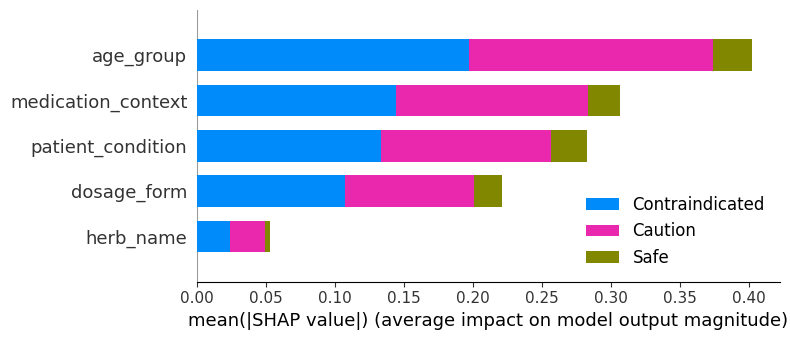

In [7]:
import shap

explainer = shap.TreeExplainer(rf)
# Explain a sample of the test set (keep it small so it renders fast)
X_sample = X_test.iloc[:200]
shap_values = explainer.shap_values(X_sample)

# Global summary (bar) across all classes
shap.summary_plot(shap_values, X_sample, feature_names=feature_columns,
                  class_names=list(target_encoder.classes_), plot_type="bar", show=True)

In [8]:
# Explain ONE prediction in plain words (useful for the app's safety note)
def explain_one(idx=0):
    row = X_sample.iloc[[idx]]
    pred_class = rf.predict(row)[0]
    pred_label = target_encoder.inverse_transform([pred_class])[0]
    # shap_values is a list per class (older shap) or 3D array (newer). Handle both.
    if isinstance(shap_values, list):
        contrib = shap_values[pred_class][idx]
    else:
        contrib = shap_values[idx, :, pred_class]
    order = np.argsort(np.abs(contrib))[::-1]
    print("Predicted risk level:", pred_label)
    print("Top contributing factors:")
    for i in order[:3]:
        col = feature_columns[i]
        val = feature_encoders[col].inverse_transform([row.iloc[0][col]])[0]
        print(f"   - {col} = '{val}'  (impact {contrib[i]:+.3f})")

explain_one(0)
print()
explain_one(1)

Predicted risk level: Contraindicated
Top contributing factors:
   - age_group = 'child'  (impact +0.323)
   - medication_context = 'none'  (impact -0.274)
   - dosage_form = 'decoction'  (impact +0.132)

Predicted risk level: Caution
Top contributing factors:
   - age_group = 'adult'  (impact +0.295)
   - medication_context = 'antidiabetic'  (impact -0.079)
   - patient_condition = 'diabetes'  (impact -0.079)


## 5. Save model artifacts

In [9]:
with open(os.path.join(MODEL_DIR, "herb_risk_random_forest_model.pkl"), "wb") as f:
    pickle.dump(rf, f)
with open(os.path.join(MODEL_DIR, "feature_label_encoders.pkl"), "wb") as f:
    pickle.dump(feature_encoders, f)
with open(os.path.join(MODEL_DIR, "target_label_encoder.pkl"), "wb") as f:
    pickle.dump(target_encoder, f)
with open(os.path.join(MODEL_DIR, "feature_columns.pkl"), "wb") as f:
    pickle.dump(feature_columns, f)

print("Saved 4 model artifacts to", MODEL_DIR)
print("Day 3 done. Next: Day 4 - Ollama + RAG answer generation.")

Saved 4 model artifacts to ..\models
Day 3 done. Next: Day 4 - Ollama + RAG answer generation.


In [10]:
from sklearn.metrics import accuracy_score, f1_score

train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc  = accuracy_score(y_test,  rf.predict(X_test))
train_f1  = f1_score(y_train, rf.predict(X_train), average="macro")
test_f1   = f1_score(y_test,  rf.predict(X_test),  average="macro")

print(f"Training accuracy : {train_acc*100:.2f}%   (n={len(y_train)})")
print(f"Testing  accuracy : {test_acc*100:.2f}%   (n={len(y_test)})")
print(f"Gap               : {(train_acc-test_acc)*100:.2f}%")
print()
print(f"Training macro-F1 : {train_f1*100:.2f}%")
print(f"Testing  macro-F1 : {test_f1*100:.2f}%")
print(f"5-fold CV         : {cv.mean()*100:.2f}% (+/- {cv.std()*100:.2f}%)")

Training accuracy : 99.96%   (n=2387)
Testing  accuracy : 89.78%   (n=597)
Gap               : 10.18%

Training macro-F1 : 99.97%
Testing  macro-F1 : 86.01%
5-fold CV         : 90.65% (+/- 0.68%)
